In [ ]:
# Do the components of a board game (complexity, number of players, playtime, number of components) affect the average user rating?

# Decision tree and Linear Regression model

import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [56]:
df = pd.read_csv(r"C:\Users\allis\Downloads\basic_data_2023.csv")


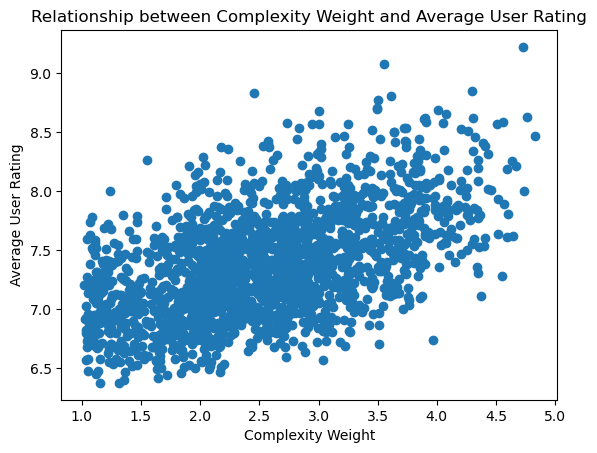

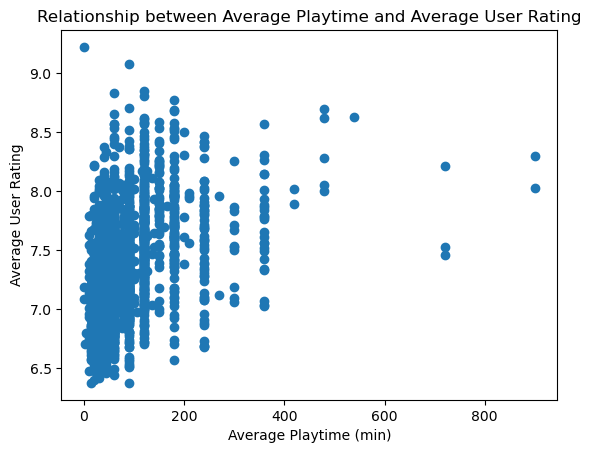

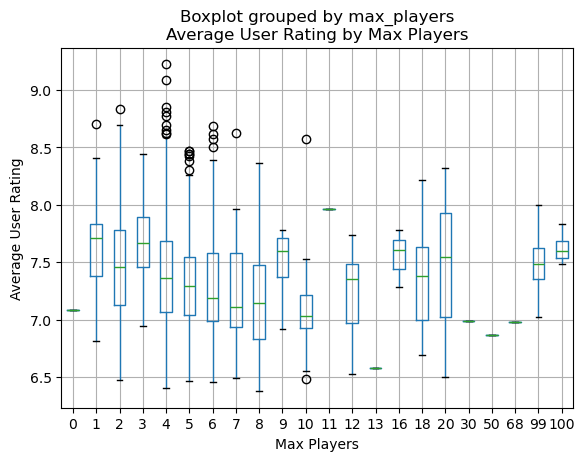

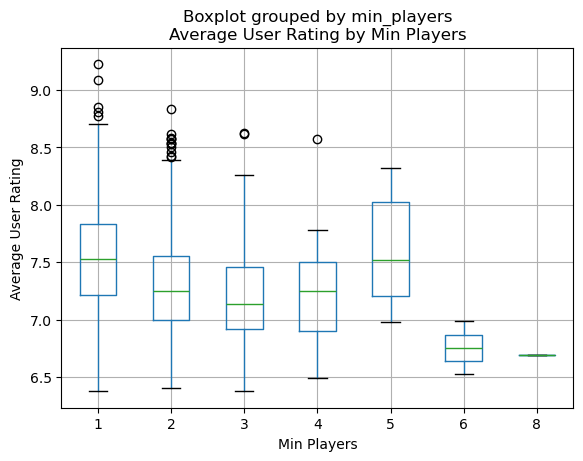

In [63]:
# visualizations to compare a few key variables:


# Includes ratings and rankings, number of players, playtime, year released, difficulty. 

# positive linear relationship
plt.figure()
plt.scatter(df["weight"], df["avg_rating"])
plt.xlabel("Complexity Weight")
plt.ylabel("Average User Rating")
plt.title("Relationship between Complexity Weight and Average User Rating")
plt.show()


# Creating list of average play time values without major outliers
average_time = []

for time in df["avg_time"]:
    if time < 999:
        average_time.append(time)
    else:
        average_time.append(None)
# slight positive linear relationship
plt.figure()
plt.scatter(average_time, df["avg_rating"])
plt.xlabel("Average Playtime (min)")
plt.ylabel("Average User Rating")
plt.title("Relationship between Average Playtime and Average User Rating")
plt.show()

# 3 to 5 is best
df.boxplot(column="avg_rating", by="max_players")
plt.xlabel("Max Players")
plt.ylabel("Average User Rating")
plt.title("Average User Rating by Max Players")
plt.show()

# lower the better but two is best
df.boxplot(column="avg_rating", by="min_players")
plt.xlabel("Min Players")
plt.ylabel("Average User Rating")
plt.title("Average User Rating by Min Players")
plt.show()





In [62]:
X = df[["weight", "max_players", "min_players", "avg_time"]]
sm.add_constant(X)
y = df[["avg_rating"]]

model = sm.OLS(y,X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:             avg_rating   R-squared (uncentered):                   0.960
Model:                            OLS   Adj. R-squared (uncentered):              0.960
Method:                 Least Squares   F-statistic:                          1.206e+04
Date:                Tue, 22 Sep 2026   Prob (F-statistic):                        0.00
Time:                        16:08:24   Log-Likelihood:                         -3610.1
No. Observations:                2000   AIC:                                      7228.
Df Residuals:                    1996   BIC:                                      7251.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------